In [1]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, LSTM, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

In [2]:
# Set directories for training and testing data
train_dir = r"C:\Users\laksh\Downloads\Project-Repository-main (2)\Project-Repository-main\dataset\Training"
test_dir = r"C:\Users\laksh\Downloads\Project-Repository-main (2)\Project-Repository-main\dataset\Testing"


In [3]:
# Set image dimensions and batch size
img_height, img_width = 299, 299  # Default input size for InceptionV3
batch_size = 20
sequence_length = 5  # Define the sequence length for LSTM

In [4]:
# Prepare ImageDataGenerators for training and testing
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)  # No data augmentation for testing

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True  # Shuffle data for better training
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 253 images belonging to 2 classes.
Found 253 images belonging to 2 classes.


In [5]:
# Load InceptionV3 as base model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

In [6]:
# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

In [7]:
# Add custom top layers for our specific classification task
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)

In [8]:
# Add LSTM layer
lstm_units = 256  # Number of units in the LSTM layer
lstm_input_features = 1024  # Number of features in the input to the LSTM layer
x = Reshape((1, lstm_input_features))(x)
x = LSTM(lstm_units, return_sequences=False)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

In [9]:
# Construct the final model
model = Model(inputs=base_model.input, outputs=predictions)

In [11]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])


In [12]:
# Model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 299, 299, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 149, 149, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 149, 149, 32)      │              96 │ conv2d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 149, 149, 32)      │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 147, 147, 32)      │           9,216 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 147, 147, 32)      │              96 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_1 (Activation)     │ (None, 147, 147, 32)      │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 147, 147, 64)      │          18,432 │ activation_1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 147, 147, 64)      │             192 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_2 (Activation)     │ (None, 147, 147, 64)      │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 73, 73, 64)        │               0 │ activation_2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 73, 73, 80)        │           5,120 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 73, 73, 80)        │             240 │ conv2d_3[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_3 (Activation)     │ (None, 73, 73, 80)        │               0 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 71, 71, 192)       │         138,240 │ activation_3[0][0]         │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 25,279,010 (96.43 MB)

 Trainable params: 3,476,226 (13.26 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [13]:
# Setup early stopping and model checkpoint
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, mode='max', restore_best_weights=True)
model_checkpoint = ModelCheckpoint('inception_lstm_model01.h5', monitor='val_loss', save_best_only=True)

In [14]:
# Fit the model
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=test_generator,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6053 - loss: 0.6722

13/13 ━━━━━━━━━━━━━━━━━━━━ 93s 6s/step - accuracy: 0.6324 - loss: 0.6504 - val_accuracy: 0.6166 - val_loss: 0.5963
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6888 - loss: 0.5800

13/13 ━━━━━━━━━━━━━━━━━━━━ 61s 5s/step - accuracy: 0.6403 - loss: 0.5989 - val_accuracy: 0.7036 - val_loss: 0.5228
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7724 - loss: 0.5324

13/13 ━━━━━━━━━━━━━━━━━━━━ 58s 5s/step - accuracy: 0.8063 - loss: 0.5125 - val_accuracy: 0.8538 - val_loss: 0.4305
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8162 - loss: 0.4582

13/13 ━━━━━━━━━━━━━━━━━━━━ 57s 5s/step - accuracy: 0.8340 - loss: 0.4364 - val_accuracy: 0.8854 - val_loss: 0.3487
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8773 - loss: 0.3883

...

13/13 ━━━━━━━━━━━━━━━━━━━━ 54s 4s/step - accuracy: 0.9802 - loss: 0.0692 - val_accuracy: 0.9960 - val_loss: 0.0255
Epoch 22/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9769 - loss: 0.0536

13/13 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - accuracy: 0.9763 - loss: 0.0638 - val_accuracy: 0.9960 - val_loss: 0.0226
Epoch 23/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 53s 4s/step - accuracy: 0.9921 - loss: 0.0395 - val_accuracy: 0.9881 - val_loss: 0.0384
Epoch 24/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9794 - loss: 0.0656

13/13 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.9802 - loss: 0.0566 - val_accuracy: 0.9921 - val_loss: 0.0172
Epoch 25/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9829 - loss: 0.0549

13/13 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.9842 - loss: 0.0473 - val_accuracy: 0.9960 - val_loss: 0.0125
Epoch 26/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9815 - loss: 0.0629

13/13 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - accuracy: 0.9842 - loss: 0.0503 - val_accuracy: 0.9960 - val_loss: 0.0091


In [15]:
# Evaluate the model
model.evaluate(test_generator)

13/13 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.9960 - loss: 0.0255


[0.025508318096399307, 0.9960474371910095]

In [16]:
train_loss_inception, train_accuracy_inception = model.evaluate(train_generator)
test_loss_inception, test_accuracy_inception = model.evaluate(test_generator)

print(f'GoogleNet Model+LSTM - Training Data: Loss = {train_loss_inception}, Accuracy = {train_accuracy_inception}')
print(f'GoogleNet Model+LSTM - Testing Data: Loss = {test_loss_inception}, Accuracy = {test_accuracy_inception}')

13/13 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.9960 - loss: 0.0255
13/13 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9960 - loss: 0.0255
GoogleNet Model+LSTM - Training Data: Loss = 0.025508319959044456, Accuracy = 0.9960474371910095
GoogleNet Model+LSTM - Testing Data: Loss = 0.025508319959044456, Accuracy = 0.9960474371910095


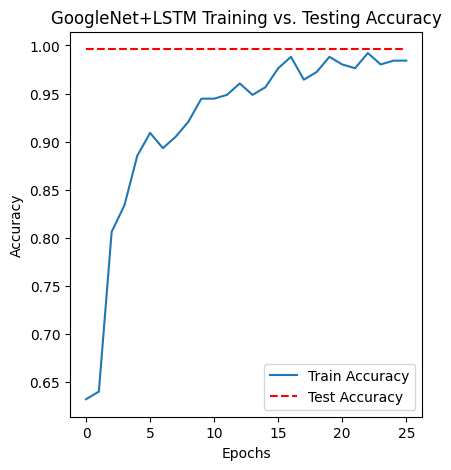

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot([0, len(history.history['accuracy']) - 1], [test_accuracy_inception, test_accuracy_inception], 'r--', label='Test Accuracy')
plt.title('GoogleNet+LSTM Training vs. Testing Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

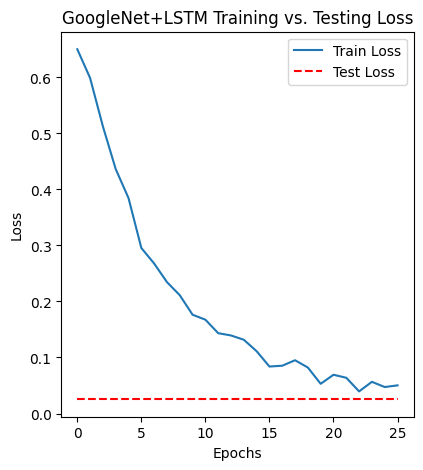

In [18]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot([0, len(history.history['loss']) - 1], [test_loss_inception, test_loss_inception], 'r--', label='Test Loss')
plt.title('GoogleNet+LSTM Training vs. Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

In [19]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, LSTM, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Set directories for training and testing data
train_dir = r"C:\Users\laksh\Downloads\Project-Repository-main (2)\Project-Repository-main\dataset\Training"
test_dir = r"C:\Users\laksh\Downloads\Project-Repository-main (2)\Project-Repository-main\dataset\Testing"
# Set image dimensions and batch size
img_height, img_width = 299, 299  # Default input size for InceptionV3
batch_size = 20
sequence_length = 5  # Define the sequence length for LSTM

# Prepare ImageDataGenerators for training and testing
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)  # No data augmentation for testing

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True  # Shuffle data for better training
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

# Load InceptionV3 as base model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# Add custom top layers for our specific classification task
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)

# Add LSTM layer
lstm_units = 256  # Number of units in the LSTM layer
lstm_input_features = 1024  # Number of features in the input to the LSTM layer
x = Reshape((1, lstm_input_features))(x)
x = LSTM(lstm_units, return_sequences=False)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

# Construct the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(lr=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()

# Setup early stopping and model checkpoint
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, mode='max', restore_best_weights=True)
model_checkpoint = ModelCheckpoint('inception_lstm_model01.h5', monitor='val_loss', save_best_only=True)

# Fit the model
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=test_generator,
    callbacks=[early_stopping, model_checkpoint]
)

# Evaluate the model
model.evaluate(test_generator)


Found 253 images belonging to 2 classes.
Found 253 images belonging to 2 classes.


ValueError: Argument(s) not recognized: {'lr': 0.0001}

In [20]:
train_loss_inception, train_accuracy_inception = model.evaluate(train_generator)
test_loss_inception, test_accuracy_inception = model.evaluate(test_generator)

print(f'GoogleNet Model+LSTM - Training Data: Loss = {train_loss_inception}, Accuracy = {train_accuracy_inception}')
print(f'GoogleNet Model+LSTM - Testing Data: Loss = {test_loss_inception}, Accuracy = {test_accuracy_inception}')

ValueError: You must call `compile()` before using the model.

In [ ]:
!pip install matplotlib

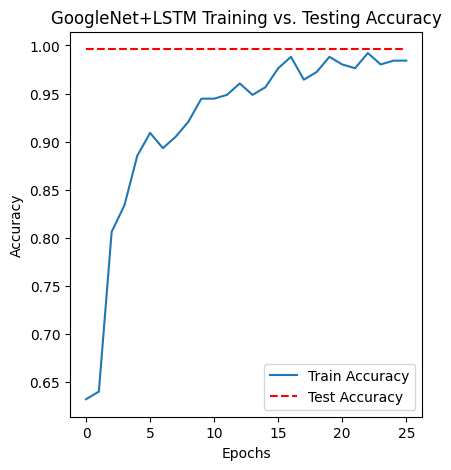

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
'''plt.plot(history.history['val_accuracy'], label='Validation Accuracy')'''
plt.plot([0, len(history.history['accuracy']) - 1], [test_accuracy_inception, test_accuracy_inception], 'r--', label='Test Accuracy')
plt.title('GoogleNet+LSTM Training vs. Testing Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

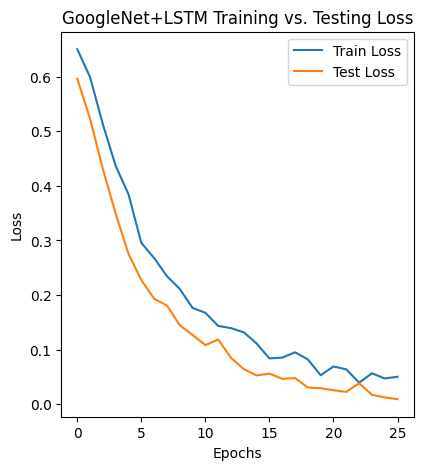

In [22]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('GoogleNet+LSTM Training vs. Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

In [3]:
import os
print(os.getcwd())


C:\Users\laksh\Downloads\Project-Repository-main (2)\Project-Repository-main\GoogleNet+LSTM


In [24]:
model.evaluate(test_generator)


ValueError: You must call `compile()` before using the model.

In [25]:
from tensorflow.keras.models import load_model

model = load_model("inception_lstm_model01.h5")


In [26]:
model.evaluate(test_generator)


13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9960 - loss: 0.0091


[0.009144299663603306, 0.9960474371910095]

In [27]:
# Evaluate on training data
train_loss, train_acc = model.evaluate(train_generator)

# Evaluate on testing data
test_loss, test_acc = model.evaluate(test_generator)

# Print results
print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)


13/13 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9960 - loss: 0.0091
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.9960 - loss: 0.0091
Training Accuracy: 0.9960474371910095
Testing Accuracy: 0.9960474371910095
